In [54]:
import torch
from torch import nn # nn contains the neural network layers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Introduction to Tensor
## creating tensors

#scalar
scalar = torch.tensor(7)
scalar

tensor(7)

In [3]:
scalar.ndim

0

In [4]:
#Get the actual value of the scalar
scalar.item()

7

In [5]:
#vector
vector = torch.tensor([7,7])
vector

tensor([7, 7])

In [6]:
vector.ndim

1

In [7]:
vector.shape

torch.Size([2])

In [8]:
#matrix
MATRIX = torch.tensor([[7,7],[7,7]])
MATRIX

tensor([[7, 7],
        [7, 7]])

In [9]:
MATRIX.ndim

2

In [10]:
#tensor
TENSOR = torch.tensor([[[7,7,7],[7,7,7],[7,7,7]]])

TENSOR

tensor([[[7, 7, 7],
         [7, 7, 7],
         [7, 7, 7]]])

In [11]:
TENSOR.ndim

3

In [12]:
TENSOR.shape

torch.Size([1, 3, 3])

In [ ]:
# Random Tensors
# start with random tensors -> look at data -> update random numbers -> look at data -> update random numbers

In [19]:
#create random tensor of size (3,4)
random_tensor = torch.rand((3, 4))
random_tensor


tensor([[0.5996, 0.1173, 0.8854, 0.8795],
        [0.0066, 0.7383, 0.6129, 0.1631],
        [0.2242, 0.4241, 0.7175, 0.7122]])

In [23]:
#create random tensor with similar shape to an image tensor
random_image_size_tensor = torch.rand(size=(3, 224, 224)) # height, width, color_channels
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([3, 224, 224]), 3)

In [25]:
# zeros and ones tensors
zeros = torch.zeros((3, 4))
zeros

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [27]:
# ones tensor
ones = torch.ones((3, 4))
ones

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [ ]:
# create a range tensor
range_tensor = torch.arange(start=0, end=10, step=2)
range_tensor

tensor([0, 2, 4, 6, 8])

In [29]:
#creating tensors-like
ten_zeroes = torch.zeros_like(range_tensor)
ten_zeroes

tensor([0, 0, 0, 0, 0])

In [ ]:
# float 32 tensor
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # what data type is the tensor
                               device=None, # where to store the tensor, CPU or GPU
                               requires_grad=False) # whether to track the gradients of the tensor
float_32_tensor

tensor([3., 6., 9.])

In [37]:
#reshape tensor
reshaped_tensor = torch.reshape(float_32_tensor, (3, 1))
reshaped_tensor

tensor([[3.],
        [6.],
        [9.]])

In [38]:
#stacking tensors
stacked_tensor = torch.stack(
    (float_32_tensor, float_32_tensor, float_32_tensor)
)
stacked_tensor

tensor([[3., 6., 9.],
        [3., 6., 9.],
        [3., 6., 9.]])

In [39]:
# view tensor
viewed_tensor = stacked_tensor.view(3, 1, 3)
viewed_tensor

tensor([[[3., 6., 9.]],

        [[3., 6., 9.]],

        [[3., 6., 9.]]])

In [41]:
#squeeze tensor
squeezed_tensor = viewed_tensor.squeeze()
squeezed_tensor

tensor([[3., 6., 9.],
        [3., 6., 9.],
        [3., 6., 9.]])

In [42]:
# unsqueeze tensor
unsqueeze_tensor = squeezed_tensor.unsqueeze(dim=0)
unsqueeze_tensor

tensor([[[3., 6., 9.],
         [3., 6., 9.],
         [3., 6., 9.]]])

In [43]:
#permutation tensor
permuted_tensor = torch.rand((3, 4, 5))
permuted_tensor

tensor([[[0.0811, 0.0165, 0.8804, 0.1083, 0.6343],
         [0.8912, 0.3785, 0.2744, 0.9370, 0.2164],
         [0.8727, 0.9955, 0.5514, 0.5459, 0.3137],
         [0.8636, 0.7324, 0.7754, 0.4116, 0.4156]],

        [[0.8601, 0.6815, 0.1601, 0.2150, 0.8869],
         [0.7729, 0.0185, 0.7090, 0.5191, 0.2526],
         [0.4556, 0.1954, 0.6281, 0.7773, 0.0686],
         [0.3503, 0.3760, 0.8386, 0.7892, 0.5279]],

        [[0.7402, 0.3514, 0.1298, 0.9106, 0.0743],
         [0.5000, 0.0462, 0.0069, 0.2503, 0.5213],
         [0.1294, 0.7933, 0.1021, 0.9378, 0.5704],
         [0.0890, 0.3936, 0.6049, 0.3863, 0.0099]]])

In [ ]:
#numpy to tensor
numpy_array = np.arange(0, 5) # create a numpy array
tensor = torch.from_numpy(numpy_array) # convert numpy array to tensor
numpy_array, tensor # view numpy array and tensor
# When converting a numpy array to a tensor, pytorch will keep the data type the same

(array([0, 1, 2, 3, 4]), tensor([0, 1, 2, 3, 4]))

In [ ]:
#random but reproducible tensors
torch.manual_seed(42) # set the random seed, so the random tensors are reproducible
random_tensor = torch.rand((2, 2))
random_tensor

tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])

In [ ]:
# pytorch workflow
#tensor -> model -> loss function -> optimizer -> training loop -> evaluation loop -> save model

In [52]:
what_were_covering = {1: "data (prepare, load, process)",
                       2: "build model",
                       3: "fittings model to data(training)",
                       4: "make predictions and evaluate a model (inference)",
                       5: "save and load model",
                       6: "putting it all together!"}

what_were_covering

{1: 'data (prepare, load, process)',
 2: 'build model',
 3: 'fittings model to data(training)',
 4: 'make predictions and evaluate a model (inference)',
 5: 'save and load model',
 6: 'putting it all together!'}

In [56]:
# 1. Data (prepare, load, process)
# lets create soem known data, using a linear regression function. We will make a straight line with known parameters, then we will try to fit a model to it

#create known paramters
weight = 0.7
bias = 0.3

#generate some random data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze to make it 2D
y = weight * X + bias # create a y value which is a function of X

X[:10], y[:10] # view the first 10 samples

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [59]:
#split data into training and test sets
split = 0.8
X_train, X_test = X[:int(len(X)*split)], X[int(len(X)*split):]
y_train, y_test = y[:int(len(y)*split)], y[int(len(y)*split):]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]))

In [ ]:
def plot_predictions(train_data, 
                     test_data, 
                     train_labels, 
                     test_labels, 
                     predictions=None):
    
    #plot the training data, test data and predictions
    plt.figure(figsize=(10, 7))
    #plot training data in blue
    plt.scatter(train_data, train_labels, c='b', label='Training data')
    #plot test data in green
    plt.scatter(test_data, test_labels, c='g', label='Testing data')
    # add predictions if passed
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', label='Predictions')
    plt.legend()
    plt.show()

# blue dot are inputs
# green dots are ideal outputs
# red dots are predictions

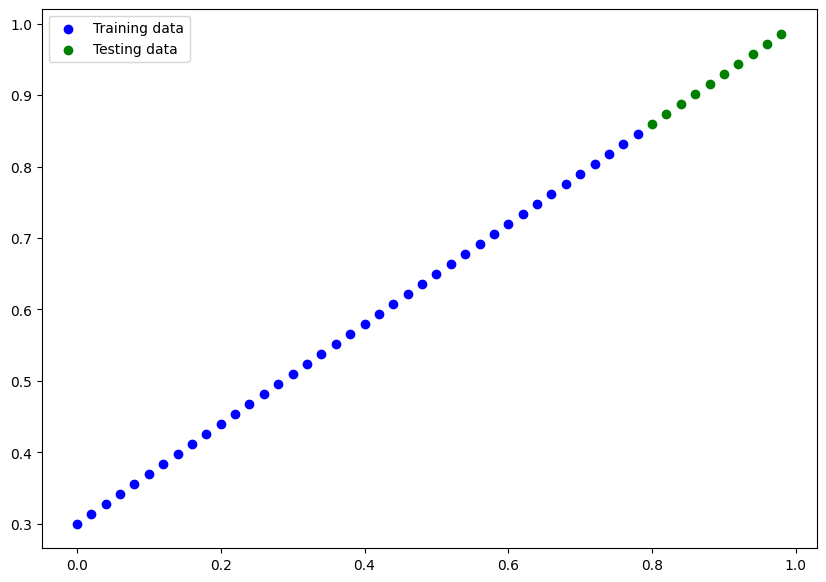

In [64]:
plot_predictions(X_train, X_test, y_train, y_test)

In [72]:
# build a model
# a model is a function that maps inputs to outputs
# starts with random parameters, then updates them to make better predictions
# using gradient descent and backpropagation

# create a linear regression model
class LinearRegressionModel(nn.Module): # inherit from nn.Module
    
    def __init__(self): # initialize the model
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor: # define the forward pass, computation from input to output
        return self.weight * x + self.bias # this is the linear regression formula
    

In [75]:
# checking contents of the model
# create a random seed
torch.manual_seed(42)

#create an instance of the model ( this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#check teh parameters of the model
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [76]:
# list naemd parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [77]:
# making predictions with torch.inference_mode()
# set the model to evaluation mode

with torch.inference_mode():
    y_preds = model_0(X_test)
    y_preds